In [ ]:
from google.colab import drive
import os
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/INDENG 290') # customize this line to your working directory

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install ortools
!pip install contextily
!pip install pulp

In [ ]:
!apt-get update
!apt-get install -y fonts-noto-cjk

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-noto-cjk is already the newest version (1:20220127+repack1-1).
0 upgraded, 0 newly installed, 0 to remove and 34 not upgraded.
Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Get:3 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:8 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [8,864 kB]
Get:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease [24.3 kB]
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InReleas

In [ ]:
# p-median求解
import pulp
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
from scipy.spatial.distance import cdist
from ortools.linear_solver import pywraplp
import folium
from folium.plugins import HeatMap

# Voronoi图分析
import geopandas as gpd
from scipy.spatial import Voronoi, voronoi_plot_2d
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, Point, MultiPolygon
from sklearn.metrics.pairwise import haversine_distances
import time
from IPython.display import IFrame


# 覆盖范围优化
from sklearn.cluster import KMeans
from scipy.optimize import minimize
from scipy.spatial.distance import cdist
from shapely.geometry import Point
import contextily as ctx
from matplotlib.colors import LinearSegmentedColormap
from datetime import datetime, timedelta
import os
import json

In [ ]:
df = pd.read_csv('processed_crash_data.csv')
df

<ipython-input-41-0975b43d1991>:1: DtypeWarning: Columns (3,15,65) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('processed_crash_data.csv')


,unique_id,cnn_intrsctn_fkey,cnn_sgmt_fkey,case_id_pkey,tb_latitude,tb_longitude,geocode_source,geocode_location,collision_datetime,collision_date,...,lighting_condition,road_condition_simple,environmental_risk_score,weather_1_simple,weather_2_simple,road_surface_condition,road_cond_1_simple,road_cond_2_simple,road_condition_combined,road_condition
0,40386,27145000.0,7847000.0,150419581,37.760300,-122.466325,SFPD-CROSSROADS,CITY STREET,2015-05-14 13:15:00,2015-05-14,...,Good,Unknown,1,Good,Unknown,Good,Unknown,Unknown,Unknown,Unknown
1,91730,24911000.0,3432000.0,240648080,37.790404,-122.406851,SFPD-INTERIM DB,CITY STREET,2024-10-15 00:29:00,2024-10-15,...,Moderate,Unknown,1,Good,Unknown,Good,Good,Unknown,Unknown,Good
2,5788,33284000.0,2800202.0,150638797,37.742285,-122.405916,SFPD-CROSSROADS,CITY STREET,2015-07-22 21:30:00,2015-07-22,...,Moderate,Unknown,1,Good,Unknown,Good,Good,Unknown,Unknown,Good
3,10457,25631000.0,NaN,3843463,37.755029,-122.425457,SFPD-CROSSROADS,CITY STREET,2008-07-27 21:00:00,2008-07-27,...,Moderate,Unknown,1,Good,Unknown,Good,Good,Unknown,Unknown,Good
4,92561,21898000.0,NaN,230757362,37.748773,-122.422571,SFPD-INTERIM DB,CITY STREET,2023-10-22 15:51:00,2023-10-22,...,Good,Unknown,5,Bad,Unknown,Poor,Unknown,Unknown,Poor,Unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61695,14294,24350000.0,NaN,130084756,37.772649,-122.415002,SFPD-CROSSROADS,CITY STREET,2013-01-29 08:20:00,2013-01-29,...,Good,Unknown,0,Good,Unknown,Good,Good,Unknown,Unknown,Good
61696,43318,27230000.0,6056201.0,150044774,37.781258,-122.458857,SFPD-CROSSROADS,CITY STREET,2015-01-15 13:39:00,2015-01-15,...,Good,Unknown,0,Good,Unknown,Good,Good,Unknown,Unknown,Good
61697,23907,24590000.0,NaN,140757357,37.785030,-122.400468,SFPD-CROSSROADS,CITY STREET,2014-09-08 18:00:00,2014-09-08,...,Good,Unknown,0,Good,Unknown,Good,Good,Unknown,Unknown,Good
61698,3235,33269000.0,NaN,150766235,37.734014,-122.390968,SFPD-CROSSROADS,CITY STREET,2015-09-01 09:35:00,2015-09-01,...,Good,Unknown,0,Good,Unknown,Good,Good,Unknown,Unknown,Good


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61700 entries, 0 to 61699
Data columns (total 99 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   unique_id                     61700 non-null  int64  
 1   cnn_intrsctn_fkey             61672 non-null  float64
 2   cnn_sgmt_fkey                 27555 non-null  float64
 3   case_id_pkey                  61700 non-null  object 
 4   tb_latitude                   61527 non-null  float64
 5   tb_longitude                  61527 non-null  float64
 6   geocode_source                61700 non-null  object 
 7   geocode_location              61700 non-null  object 
 8   collision_datetime            61700 non-null  object 
 9   collision_date                61700 non-null  object 
 10  collision_time                61700 non-null  object 
 11  accident_year                 61700 non-null  int64  
 12  month                         61700 non-null  int64  
 13  d

| 输入变量       | 说明                             | 结构示例               |
|:---------------|:----------------------------------|:------------------------|
| Demand Points  | 事故发生的位置（经纬度）           | (n, 2) 例如 [[37.77, -122.41], [37.78, -122.42], ...] |
| Demand Weights | 每个事故点的重要性权重（归一化）    | (n,) 例如 [0.82, 0.65, 0.97, ...] |
| Potential Sites| 潜在救护站的位置（经纬度）          | (m, 2) 例如 [[37.75, -122.45], [37.78, -122.39], ...] |

In [ ]:
def prepare_recent_p_median_data(df, months=6):
    """
    准备最近指定月份的p-中值问题数据

    Parameters:
    -----------
    df : pandas.DataFrame
        事故数据
    months : int
        最近几个月的数据，默认为6个月

    Returns:
    --------
    tuple : (demand_points, weights, potential_sites)
    """
    print(f"准备最近{months}个月的事故数据...")

    # 1. 时间过滤 - 只保留最近N个月的数据
    if 'collision_date' in df.columns:
        # 将日期列转换为datetime格式
        df['collision_date'] = pd.to_datetime(df['collision_date'], errors='coerce')

        # 计算截止日期（当前日期往前推N个月）
        cutoff_date = datetime.now() - timedelta(days=30*months)

        # 过滤数据
        recent_df = df[df['collision_date'] >= cutoff_date].copy()
        print(f"从 {len(df)} 条记录中筛选出 {len(recent_df)} 条最近{months}个月的记录")
    else:
        print("警告: 找不到日期列，使用全部数据")
        recent_df = df.copy()

    # 2. 继续常规的数据准备流程
    # 数据清洗 - 移除坐标缺失的记录
    clean_df = recent_df.dropna(subset=['tb_latitude', 'tb_longitude']).copy()

    # 准备需求点（事故发生位置）
    demand_points = clean_df[['tb_latitude', 'tb_longitude']].values

    # 计算权重
    weights = calculate_demand_weights(clean_df)

    # 生成潜在站点
    potential_sites = generate_potential_sites(clean_df)

    # 验证数据完整性
    demand_points, weights, potential_sites = validate_and_clean_data(
        demand_points, weights, potential_sites
    )

    return demand_points, weights, potential_sites

def calculate_demand_weights(df):
    """
    计算需求点权重，考虑多个因素
    """
    weights = np.zeros(len(df))

    # 1. 事故严重性权重
    severity_map = {
        'Fatal': 5.0,
        'Injury (Severe)': 4.0,
        'Injury (Other Visible)': 3.0,
        'Injury (Complaint of Pain)': 2.0,
        'Property Damage Only': 1.0
    }

    if 'collision_severity' in df.columns:
        severity_weights = df['collision_severity'].map(severity_map).fillna(1.0)
        weights += severity_weights

    # 2. 伤亡人数权重
    if 'number_killed' in df.columns:
        weights += df['number_killed'].fillna(0) * 5.0

    if 'number_injured' in df.columns:
        weights += df['number_injured'].fillna(0) * 2.0

    # 3. 特殊事故类型权重
    if 'involves_pedestrian' in df.columns:
        weights += df['involves_pedestrian'].fillna(0) * 1.5

    if 'involves_bicycle' in df.columns:
        weights += df['involves_bicycle'].fillna(0) * 1.2

    # 4. 时间因素权重
    if 'is_rush_hour' in df.columns:
        weights += df['is_rush_hour'].fillna(0) * 1.1

    # 5. 日期权重 - 越近的事故权重越高
    if 'collision_date' in df.columns and pd.api.types.is_datetime64_any_dtype(df['collision_date']):
        # 计算每个事故到现在的天数
        now = datetime.now()
        days_ago = (now - df['collision_date']).dt.days

        # 归一化成0-1的权重（最近的事故接近1，最远的接近0）
        max_days = days_ago.max()
        if max_days > 0:  # 避免除以零
            recency_weight = 1 - (days_ago / max_days)
            weights += recency_weight

    # 6. 归一化权重
    if weights.max() > 0:
        weights = weights / weights.max()
    else:
        weights = np.ones(len(df))  # 如果所有权重都是0，则使用均匀权重

    return weights

def generate_potential_sites(df, method='hybrid', n_sites=40):
    """
    生成潜在站点位置
    """
    coords = df[['tb_latitude', 'tb_longitude']].values
    weights = calculate_demand_weights(df)

    # 确保数据有效
    valid_mask = ~np.any(np.isnan(coords), axis=1)
    coords = coords[valid_mask]
    weights = weights[valid_mask]

    if method == 'grid':
        # 网格法
        lat_min, lat_max = coords[:, 0].min(), coords[:, 0].max()
        lon_min, lon_max = coords[:, 1].min(), coords[:, 1].max()

        grid_size = int(np.sqrt(n_sites))
        lat_grid = np.linspace(lat_min, lat_max, grid_size)
        lon_grid = np.linspace(lon_min, lon_max, grid_size)

        sites = []
        for lat in lat_grid:
            for lon in lon_grid:
                sites.append([lat, lon])

        potential_sites = np.array(sites)

    elif method == 'kmeans':
        # K-means聚类法
        if len(coords) > 0:
            kmeans = KMeans(n_clusters=n_sites, random_state=42)
            kmeans.fit(coords, sample_weight=weights)
            potential_sites = kmeans.cluster_centers_
        else:
            potential_sites = np.array([])

    elif method == 'hybrid':
        # 混合方法：结合K-means和高风险区域
        # 使用K-means找到初始位置
        n_kmeans = n_sites // 2
        if len(coords) > 0:
            kmeans = KMeans(n_clusters=n_kmeans, random_state=42)
            kmeans.fit(coords, sample_weight=weights)
            kmeans_sites = kmeans.cluster_centers_
        else:
            kmeans_sites = np.array([])

        # 在高权重区域添加额外站点
        if 'analysis_neighborhood' in df.columns:
            neighborhood_stats = df.groupby('analysis_neighborhood').agg({
                'tb_latitude': 'mean',
                'tb_longitude': 'mean',
                'total_casualties': 'sum' if 'total_casualties' in df.columns else 'count'
            }).reset_index()

            # 选择事故最多的区域
            n_high_risk = n_sites - n_kmeans
            high_risk_areas = neighborhood_stats.nlargest(n_high_risk, 'total_casualties')
            high_risk_sites = high_risk_areas[['tb_latitude', 'tb_longitude']].values
        else:
            # 如果没有区域信息，使用高密度区域
            density_threshold = np.percentile(weights, 75)
            high_weight_mask = weights > density_threshold
            if np.any(high_weight_mask):
                high_density_coords = coords[high_weight_mask]
                n_high_risk = n_sites - n_kmeans
                if len(high_density_coords) > n_high_risk:
                    # 从高密度区域随机选择
                    indices = np.random.choice(len(high_density_coords), n_high_risk, replace=False)
                    high_risk_sites = high_density_coords[indices]
                else:
                    high_risk_sites = high_density_coords
            else:
                high_risk_sites = np.array([])

        # 合并站点
        if len(kmeans_sites) > 0 and len(high_risk_sites) > 0:
            potential_sites = np.vstack([kmeans_sites, high_risk_sites])
        elif len(kmeans_sites) > 0:
            potential_sites = kmeans_sites
        elif len(high_risk_sites) > 0:
            potential_sites = high_risk_sites
        else:
            potential_sites = np.array([])

    return potential_sites

def validate_and_clean_data(demand_points, weights, potential_sites):
    """
    验证和清理数据，确保没有NaN或无效值
    """
    # 清理需求点
    valid_demand_mask = ~np.any(np.isnan(demand_points), axis=1)
    demand_points_clean = demand_points[valid_demand_mask]
    weights_clean = weights[valid_demand_mask]

    # 清理潜在站点
    valid_sites_mask = ~np.any(np.isnan(potential_sites), axis=1)
    potential_sites_clean = potential_sites[valid_sites_mask]

    # 确保权重没有NaN
    weights_clean = np.nan_to_num(weights_clean, nan=1.0)

    # 如果数据为空，抛出警告
    if len(demand_points_clean) == 0:
        raise ValueError("没有有效的需求点数据")

    if len(potential_sites_clean) == 0:
        raise ValueError("没有有效的潜在站点数据")

    # 打印验证信息
    print(f"有效需求点数量: {len(demand_points_clean)}")
    print(f"有效潜在站点数量: {len(potential_sites_clean)}")
    print(f"权重范围: {weights_clean.min():.2f} - {weights_clean.max():.2f}")

    return demand_points_clean, weights_clean, potential_sites_clean

In [ ]:
# 调用最近6个月的数据准备函数
demand_points, weights, potential_sites = prepare_recent_p_median_data(df, months=12)

准备最近12个月的事故数据...
从 61700 条记录中筛选出 2448 条最近12个月的记录
有效需求点数量: 2429
有效潜在站点数量: 40
权重范围: 0.09 - 1.00


In [ ]:
# 计算距离矩阵
distances = cdist(demand_points, potential_sites)

In [ ]:
# 验证结果
print("数据准备完成:")
print(f"- 需求点数量: {len(demand_points)}")
print(f"- 潜在站点数量: {len(potential_sites)}")
print(f"- 距离矩阵形状: {distances.shape}")
print(f"- 距离矩阵包含NaN: {np.isnan(distances).any()}")
print(f"- 权重包含NaN: {np.isnan(weights).any()}")

数据准备完成:
- 需求点数量: 2429
- 潜在站点数量: 40
- 距离矩阵形状: (2429, 40)
- 距离矩阵包含NaN: False
- 权重包含NaN: False


# 🚑 CrashSight SF - p-Median Optimization Overview

## 📚 Problem Definition

The **p-Median Problem** seeks to determine the optimal locations for **p facilities** (e.g., ambulance stations) from a set of candidate sites, in order to **minimize the total weighted distance** between demand points (e.g., accident locations) and their assigned facilities.

Formally:

- Given:
  - A set of **n demand points** with coordinates and weights (e.g., accident frequencies, population density).
  - A set of **m potential facility sites** with coordinates.
- Goal:
  - Select **p sites** among m candidates.
  - Assign each demand point to a selected facility.
  - **Minimize** the sum of weighted Euclidean distances between demand points and their assigned facilities.

---

## 🛠 Implementation

### `PMedianSolver` Class

- **Inputs**:
  - `demand_points`: array of demand point coordinates (n × 2).
  - `potential_sites`: array of potential site coordinates (m × 2).
  - `weights`: array of importance weights for each demand point.
  - `p`: number of facilities to establish.

- **Process**:
  - Precompute all pairwise distances between demand points and potential sites.
  - Set up a **linear programming model** using `PuLP`:
    - **Decision variables**:
      - `x[i,j] = 1` if demand point i is assigned to site j.
      - `y[j] = 1` if site j is selected.
    - **Objective**:
      - Minimize total weighted distance:  
        $$\text{Minimize} \quad \sum_i \sum_j (\text{weight}_i \times \text{distance}_{ij} \times x_{ij})$$
    - **Constraints**:
      1. Each demand point must be assigned to exactly one site.
      2. Demand points can only be assigned to selected sites.
      3. Exactly p sites must be selected.

- **Outputs**:
  - `selected_sites`: Indices of selected facility sites.
  - `assignments`: Mapping of each demand point to a selected site.
  - `coverage_cost`: Total minimized weighted distance.

---

### `apply_to_crashsight_sf` Function

- Prepares the input data for `PMedianSolver`:
  - Accident location coordinates as demand points.
  - Population density as demand weights (or simple uniform weights).
  - Potential station locations.
- Solves the p-Median problem for CrashSight SF.
- Returns:
  - Selected station locations.
  - Demand point assignments.
  - Total coverage cost.

---

## 🎯 Why p-Median for CrashSight SF?

- Accurately models the goal of minimizing average response distance to crash hotspots.
- Considers both **spatial distribution** (accident locations) and **importance weighting** (e.g., population density, crash severity).
- Provides a practical basis for **emergency resource planning**, especially under limited resource constraints.

---

## ✅ Key Benefits

- **Data-driven optimization** of station layouts.
- **Minimized weighted response time** for high-risk crash areas.
- **Scalable** to larger datasets and adjustable for different scenarios (e.g., more stations, different weighting).



In [ ]:
class PMedainSolver:
    """
    P-Median问题求解器
    """
    def __init__(self, demand_points=None, weights=None, potential_sites=None, df=None, months=12):
        """
        初始化P-median求解器

        Parameters:
        -----------
        demand_points : array-like, shape (n_demands, 2), optional
            需求点坐标，如果提供了df则不需要
        weights : array-like, shape (n_demands,), optional
            需求点权重，如果提供了df则不需要
        potential_sites : array-like, shape (n_sites, 2), optional
            潜在站点坐标，如果提供了df则不需要
        df : pandas.DataFrame, optional
            如果提供，会调用prepare_recent_p_median_data准备最近months个月的数据
        months : int
            最近几个月的数据，默认为12个月
        """
        if df is not None:
            # 如果提供了DataFrame，使用最近数据
            print(f"使用最近{months}个月的数据...")
            self.demand_points, self.weights, self.potential_sites = prepare_recent_p_median_data(df, months)
        else:
            # 否则使用直接提供的数据
            self.demand_points = np.array(demand_points)
            self.weights = np.array(weights)
            self.potential_sites = np.array(potential_sites)

        # 计算距离矩阵
        self.distance_matrix = None
        if len(self.demand_points) * len(self.potential_sites) < 10000000:  # 约10M的矩阵元素
            print("预计算距离矩阵...")
            self.distance_matrix = self._calculate_distance_matrix()
        else:
            print("数据规模较大，将使用按需计算距离...")

        print(f"P-Median求解器初始化完成:")
        print(f"需求点数量: {len(self.demand_points)}")
        print(f"潜在站点数量: {len(self.potential_sites)}")

    def _calculate_distance_matrix(self):
        """
        计算需求点和潜在站点之间的距离矩阵
        使用Haversine公式计算地理距离
        """
        # 将经纬度转换为弧度
        demand_rad = np.radians(self.demand_points)
        sites_rad = np.radians(self.potential_sites)

        # 计算距离矩阵
        distances = haversine_distances(demand_rad, sites_rad) * 6371  # 地球半径（公里）
        return distances

    def _calculate_batch_distances(self, points1, points2, batch_size=1000):
        """
        分批计算两组点之间的Haversine距离矩阵（公里）
        """
        n1 = len(points1)
        n2 = len(points2)
        distance_matrix = np.zeros((n1, n2))

        # 将points2转换为弧度
        points2_rad = np.radians(points2)

        # 分批处理points1
        for i in range(0, n1, batch_size):
            end = min(i + batch_size, n1)
            # 将当前批次的points1转换为弧度
            points1_batch_rad = np.radians(points1[i:end])

            # 计算当前批次的距离矩阵
            batch_distances = haversine_distances(points1_batch_rad, points2_rad) * 6371  # 地球半径（公里）

            # 存储结果
            distance_matrix[i:end, :] = batch_distances

        return distance_matrix

    def solve_greedy(self, p_facilities, max_distance=None):
        """
        使用贪心算法求解p-median问题

        Parameters:
        -----------
        p_facilities : int
            要建立的站点数量
        max_distance : float, optional
            最大覆盖距离（公里）

        Returns:
        --------
        dict : 包含求解结果的字典
        """
        start_time = time.time()
        print(f"\n开始贪心算法求解 P-Median 问题 (p={p_facilities})")

        n_demands = len(self.demand_points)
        n_sites = len(self.potential_sites)

        # 初始化
        selected_indices = []
        unselected_indices = list(range(n_sites))

        for k in range(p_facilities):
            print(f"选择第 {k+1}/{p_facilities} 个站点...")

            best_cost = float('inf')
            best_index = None

            for j in unselected_indices:
                # 临时将当前站点加入已选列表
                temp_selected = selected_indices + [j]

                # 计算总成本
                if self.distance_matrix is not None:
                    # 使用预先计算的距离矩阵
                    # 对每个需求点，找到最近的已选站点
                    min_distances = np.min(self.distance_matrix[:, temp_selected], axis=1)
                    # 应用最大距离约束（如果有）
                    if max_distance is not None:
                        min_distances = np.minimum(min_distances, max_distance)
                    # 计算加权总距离
                    total_cost = np.sum(min_distances * self.weights)
                else:
                    # 动态计算距离
                    total_cost = 0
                    batch_size = 1000  # 每批处理的需求点数量

                    for i in range(0, n_demands, batch_size):
                        end = min(i + batch_size, n_demands)
                        batch_demands = self.demand_points[i:end]
                        batch_weights = self.weights[i:end]

                        # 计算这批需求点到所有已选站点的距离
                        batch_distances = self._calculate_batch_distances(
                            batch_demands,
                            self.potential_sites[temp_selected]
                        )

                        # 找到每个需求点到最近站点的距离
                        min_distances = np.min(batch_distances, axis=1)

                        # 应用最大距离约束（如果有）
                        if max_distance is not None:
                            min_distances = np.minimum(min_distances, max_distance)

                        # 累加加权距离
                        total_cost += np.sum(min_distances * batch_weights)

                # 更新最佳选择
                if total_cost < best_cost:
                    best_cost = total_cost
                    best_index = j

            # 添加最佳站点
            if best_index is not None:
                selected_indices.append(best_index)
                unselected_indices.remove(best_index)
                print(f"  选择站点 {best_index}, 当前成本: {best_cost:.2f}")
            else:
                print("  未找到有效站点")

        # 计算分配和指标
        print("计算最终分配和性能指标...")

        # 计算分配，总成本和覆盖率
        assignments, total_cost, coverage, avg_distance = self._compute_solution_metrics(
            selected_indices, self.distance_matrix, self.distance_matrix is not None, max_distance
        )

        # 组装结果
        results = {
            'selected_sites': selected_indices,
            'assignments': assignments,
            'total_cost': total_cost,
            'coverage': coverage,
            'avg_distance': avg_distance,
            'status': 'OPTIMAL' if len(selected_indices) == p_facilities else 'SUBOPTIMAL',
            'solve_time': time.time() - start_time,
            'site_coordinates': {idx: self.potential_sites[idx] for idx in selected_indices}
        }

        print(f"求解完成，用时: {results['solve_time']:.2f} 秒")

        return results

    def _compute_solution_metrics(self, selected_indices, distance_matrix=None,
                                 distance_matrix_computed=False, max_distance=None):
        """
        计算解决方案的指标
        """
        n_demands = len(self.demand_points)

        # 初始化
        assignments = {}
        total_cost = 0
        coverage = {j: 0 for j in selected_indices}

        if distance_matrix_computed and distance_matrix is not None:
            # 使用预先计算的距离矩阵
            # 对每个需求点找到最近的已选站点
            selected_distances = distance_matrix[:, selected_indices]
            nearest_indices = np.argmin(selected_distances, axis=1)
            min_distances = np.min(selected_distances, axis=1)

            # 应用最大距离约束（如果有）
            if max_distance is not None:
                covered_mask = min_distances <= max_distance
            else:
                covered_mask = np.ones(n_demands, dtype=bool)

            # 创建分配和计算成本
            for i in range(n_demands):
                if covered_mask[i]:
                    site_idx = selected_indices[nearest_indices[i]]
                    assignments[i] = site_idx
                    total_cost += self.weights[i] * min_distances[i]
                    coverage[site_idx] += 1
        else:
            # 分批处理需求点
            batch_size = 1000
            for i in range(0, n_demands, batch_size):
                end = min(i + batch_size, n_demands)
                batch_demands = self.demand_points[i:end]
                batch_weights = self.weights[i:end]

                # 计算这批需求点到所有已选站点的距离
                batch_distances = self._calculate_batch_distances(
                    batch_demands,
                    self.potential_sites[selected_indices]
                )

                # 找到每个需求点到最近站点的索引和距离
                nearest_indices = np.argmin(batch_distances, axis=1)
                min_distances = np.min(batch_distances, axis=1)

                # 应用最大距离约束（如果有）
                if max_distance is not None:
                    covered_mask = min_distances <= max_distance
                else:
                    covered_mask = np.ones(end-i, dtype=bool)

                # 创建分配和计算成本
                for j in range(end-i):
                    if covered_mask[j]:
                        demand_idx = i + j
                        site_idx = selected_indices[nearest_indices[j]]
                        assignments[demand_idx] = site_idx
                        total_cost += batch_weights[j] * min_distances[j]
                        coverage[site_idx] += 1

        # 计算平均覆盖距离
        if np.sum(self.weights) > 0:
            avg_distance = total_cost / np.sum(self.weights)
        else:
            avg_distance = 0

        return assignments, total_cost, coverage, avg_distance

    def visualize_results(self, results, output_file='emergency_stations_map.html'):
        """
        可视化求解结果
        """
        if results['status'] not in ['OPTIMAL', 'SUBOPTIMAL']:
            print("无法可视化：未找到有效解")
            return

        # 创建地图
        center_lat = np.mean(self.demand_points[:, 0])
        center_lon = np.mean(self.demand_points[:, 1])
        m = folium.Map(location=[center_lat, center_lon], zoom_start=12)

        # 添加需求点热力图（使用采样以减少点数）
        if len(self.demand_points) > 2000:
            # 如果点太多，随机采样
            sample_size = 2000
            indices = np.random.choice(len(self.demand_points), sample_size, replace=False)
            sampled_points = self.demand_points[indices]
            sampled_weights = self.weights[indices]
            heat_data = [[point[0], point[1], weight]
                         for point, weight in zip(sampled_points, sampled_weights)]
        else:
            heat_data = [[point[0], point[1], weight]
                         for point, weight in zip(self.demand_points, self.weights)]

        HeatMap(heat_data, radius=15).add_to(m)

        # 添加选中的站点
        for site_idx in results['selected_sites']:
            site = self.potential_sites[site_idx]
            coverage_count = results['coverage'].get(site_idx, 0)

            folium.Marker(
                location=[site[0], site[1]],
                popup=f"站点 {site_idx}<br>覆盖需求点: {coverage_count}",
                icon=folium.Icon(color='red', icon='info-sign')
            ).add_to(m)

        # 保存地图
        m.save(output_file)
        print(f"地图已保存到 {output_file}")

        return m

    def analyze_solution(self, results):
        """
        分析求解结果
        """
        if results['status'] not in ['OPTIMAL', 'SUBOPTIMAL']:
            print("无法分析：未找到有效解")
            return None

        # 计算覆盖率
        total_demand = len(self.demand_points)
        coverage_count = len(results['assignments'])
        coverage_rate = coverage_count / total_demand if total_demand > 0 else 0

        # 计算每个站点的服务半径
        service_radius = {}

        for site_idx in results['selected_sites']:
            # 找到分配给该站点的所有需求点
            assigned_demands = []
            assigned_weights = []

            for demand_idx, assigned_site in results['assignments'].items():
                if assigned_site == site_idx:
                    assigned_demands.append(self.demand_points[demand_idx])
                    assigned_weights.append(self.weights[demand_idx])

            if assigned_demands:
                # 转换为数组
                assigned_demands = np.array(assigned_demands)
                assigned_weights = np.array(assigned_weights)

                # 计算到站点的距离
                site_location = self.potential_sites[site_idx].reshape(1, -1)
                distances = self._calculate_batch_distances(assigned_demands, site_location)[:, 0]

                service_radius[site_idx] = {
                    'max_distance': float(np.max(distances)),
                    'avg_distance': float(np.average(distances, weights=assigned_weights)),
                    'demand_count': len(assigned_demands),
                    'total_weight': float(np.sum(assigned_weights))
                }

        # 打印分析结果
        print("\n=== P-Median问题求解结果分析 ===")
        print(f"选中站点数量: {len(results['selected_sites'])}")
        print(f"总成本（加权距离）: {results['total_cost']:.2f}")
        print(f"平均覆盖距离: {results['avg_distance']:.2f} 公里")
        print(f"覆盖率: {coverage_rate * 100:.1f}% ({coverage_count}/{total_demand})")
        print(f"求解时间: {results['solve_time']:.2f} 秒")

        print("\n各站点服务情况:")
        for site_idx, stats in service_radius.items():
            print(f"站点 {site_idx}:")
            print(f"  - 覆盖需求点数: {stats['demand_count']}")
            print(f"  - 总权重: {stats['total_weight']:.2f}")
            print(f"  - 最大服务距离: {stats['max_distance']:.2f} 公里")
            print(f"  - 平均服务距离: {stats['avg_distance']:.2f} 公里")

        # 返回分析结果
        analysis_results = {
            'coverage_rate': coverage_rate,
            'coverage_count': coverage_count,
            'service_radius': service_radius
        }

        return analysis_results

In [ ]:
# 开设八个站点
solver_P8 = PMedainSolver(
    demand_points=demand_points,
    weights=weights,
    potential_sites=potential_sites
)

# 然后继续正常求解
results_P8 = solver_P8.solve_greedy(p_facilities=8)

# 分析结果
analysis_P8 = solver_P8.analyze_solution(results_P8)

# 可视化
solver_P8.visualize_results(results_P8, output_file='emergency_stations_map.html')

预计算距离矩阵...
P-Median求解器初始化完成:
需求点数量: 2429
潜在站点数量: 40

开始贪心算法求解 P-Median 问题 (p=8)
选择第 1/8 个站点...
  选择站点 1, 当前成本: 1865.09
选择第 2/8 个站点...
  选择站点 29, 当前成本: 1521.37
选择第 3/8 个站点...
  选择站点 3, 当前成本: 1203.72
选择第 4/8 个站点...
  选择站点 22, 当前成本: 1004.77
选择第 5/8 个站点...
  选择站点 10, 当前成本: 874.47
选择第 6/8 个站点...
  选择站点 28, 当前成本: 809.16
选择第 7/8 个站点...
  选择站点 25, 当前成本: 745.96
选择第 8/8 个站点...
  选择站点 4, 当前成本: 693.81
计算最终分配和性能指标...
求解完成，用时: 0.02 秒

=== P-Median问题求解结果分析 ===
选中站点数量: 8
总成本（加权距离）: 693.81
平均覆盖距离: 1.19 公里
覆盖率: 100.0% (2429/2429)
求解时间: 0.02 秒

各站点服务情况:
站点 1:
  - 覆盖需求点数: 365
  - 总权重: 87.10
  - 最大服务距离: 2.50 公里
  - 平均服务距离: 0.92 公里
站点 29:
  - 覆盖需求点数: 169
  - 总权重: 42.87
  - 最大服务距离: 4.08 公里
  - 平均服务距离: 1.91 公里
站点 3:
  - 覆盖需求点数: 648
  - 总权重: 152.46
  - 最大服务距离: 4.78 公里
  - 平均服务距离: 1.10 公里
站点 22:
  - 覆盖需求点数: 218
  - 总权重: 52.89
  - 最大服务距离: 2.87 公里
  - 平均服务距离: 1.26 公里
站点 10:
  - 覆盖需求点数: 218
  - 总权重: 53.32
  - 最大服务距离: 3.75 公里
  - 平均服务距离: 1.53 公里
站点 28:
  - 覆盖需求点数: 176
  - 总权重: 43.31
  - 最大服务距离: 2.96 公里
  - 平均服务距离: 

In [ ]:
_# 直接用准备好的数据初始化
solver_P10 = PMedainSolver(
    demand_points=demand_points,
    weights=weights,
    potential_sites=potential_sites
)

# 然后继续正常求解
results_P10 = solver_P10.solve_greedy(p_facilities=10)

# 分析结果
analysis_P10 = solver_P10.analyze_solution(results_P10)

# 可视化
solver_P10.visualize_results(results_P10, output_file='emergency_stations_map.html')

预计算距离矩阵...
P-Median求解器初始化完成:
需求点数量: 2429
潜在站点数量: 40

开始贪心算法求解 P-Median 问题 (p=10)
选择第 1/10 个站点...
  选择站点 1, 当前成本: 1865.09
选择第 2/10 个站点...
  选择站点 29, 当前成本: 1521.37
选择第 3/10 个站点...
  选择站点 3, 当前成本: 1203.72
选择第 4/10 个站点...
  选择站点 22, 当前成本: 1004.77
选择第 5/10 个站点...
  选择站点 10, 当前成本: 874.47
选择第 6/10 个站点...
  选择站点 28, 当前成本: 809.16
选择第 7/10 个站点...
  选择站点 25, 当前成本: 745.96
选择第 8/10 个站点...
  选择站点 4, 当前成本: 693.81
选择第 9/10 个站点...
  选择站点 16, 当前成本: 657.16
选择第 10/10 个站点...
  选择站点 15, 当前成本: 625.14
计算最终分配和性能指标...
求解完成，用时: 0.02 秒

=== P-Median问题求解结果分析 ===
选中站点数量: 10
总成本（加权距离）: 625.14
平均覆盖距离: 1.07 公里
覆盖率: 100.0% (2429/2429)
求解时间: 0.02 秒

各站点服务情况:
站点 1:
  - 覆盖需求点数: 266
  - 总权重: 63.40
  - 最大服务距离: 2.50 公里
  - 平均服务距离: 0.78 公里
站点 29:
  - 覆盖需求点数: 169
  - 总权重: 42.87
  - 最大服务距离: 4.08 公里
  - 平均服务距离: 1.91 公里
站点 3:
  - 覆盖需求点数: 419
  - 总权重: 96.91
  - 最大服务距离: 4.78 公里
  - 平均服务距离: 0.96 公里
站点 22:
  - 覆盖需求点数: 218
  - 总权重: 52.89
  - 最大服务距离: 2.87 公里
  - 平均服务距离: 1.26 公里
站点 10:
  - 覆盖需求点数: 218
  - 总权重: 53.32
  - 最大服务距离: 3.75 公里


In [ ]:
# 开设12个站点
solver_P12 = PMedainSolver(
    demand_points=demand_points,
    weights=weights,
    potential_sites=potential_sites
)

# 然后继续正常求解
results_P12 = solver_P12.solve_greedy(p_facilities=12)

# 分析结果
analysis_P12 = solver_P12.analyze_solution(results_P12)

# 可视化
solver_P12.visualize_results(results_P12, output_file='emergency_stations_map.html')

预计算距离矩阵...
P-Median求解器初始化完成:
需求点数量: 2429
潜在站点数量: 40

开始贪心算法求解 P-Median 问题 (p=12)
选择第 1/12 个站点...
  选择站点 1, 当前成本: 1865.09
选择第 2/12 个站点...
  选择站点 29, 当前成本: 1521.37
选择第 3/12 个站点...
  选择站点 3, 当前成本: 1203.72
选择第 4/12 个站点...
  选择站点 22, 当前成本: 1004.77
选择第 5/12 个站点...
  选择站点 10, 当前成本: 874.47
选择第 6/12 个站点...
  选择站点 28, 当前成本: 809.16
选择第 7/12 个站点...
  选择站点 25, 当前成本: 745.96
选择第 8/12 个站点...
  选择站点 4, 当前成本: 693.81
选择第 9/12 个站点...
  选择站点 16, 当前成本: 657.16
选择第 10/12 个站点...
  选择站点 15, 当前成本: 625.14
选择第 11/12 个站点...
  选择站点 23, 当前成本: 596.92
选择第 12/12 个站点...
  选择站点 11, 当前成本: 570.14
计算最终分配和性能指标...
求解完成，用时: 0.03 秒

=== P-Median问题求解结果分析 ===
选中站点数量: 12
总成本（加权距离）: 570.14
平均覆盖距离: 0.98 公里
覆盖率: 100.0% (2429/2429)
求解时间: 0.03 秒

各站点服务情况:
站点 1:
  - 覆盖需求点数: 242
  - 总权重: 58.14
  - 最大服务距离: 1.57 公里
  - 平均服务距离: 0.68 公里
站点 29:
  - 覆盖需求点数: 169
  - 总权重: 42.87
  - 最大服务距离: 4.08 公里
  - 平均服务距离: 1.91 公里
站点 3:
  - 覆盖需求点数: 222
  - 总权重: 50.59
  - 最大服务距离: 1.09 公里
  - 平均服务距离: 0.54 公里
站点 22:
  - 覆盖需求点数: 218
  - 总权重: 52.89
  - 最大服务距离: 2.87

In [ ]:
# 收集三组结果
comparison_df = pd.DataFrame({
    '站点数量 (p)': [8, 10, 12],
    '总加权距离': [results_P8['total_cost'], results_P10['total_cost'], results_P12['total_cost']],
    '平均覆盖距离 (公里)': [results_P8['avg_distance'], results_P10['avg_distance'], results_P12['avg_distance']],
    '覆盖率 (%)': [
        len(results_P8['assignments']) / len(solver_P8.demand_points) * 100,
        len(results_P10['assignments']) / len(solver_P10.demand_points) * 100,
        len(results_P12['assignments']) / len(solver_P12.demand_points) * 100
    ],
    '求解时间 (秒)': [results_P8['solve_time'], results_P10['solve_time'], results_P12['solve_time']]
})

# 显示对比表
comparison_df

,站点数量 (p),总加权距离,平均覆盖距离 (公里),覆盖率 (%),求解时间 (秒)
0,8,693.806041,1.189125,100.0,0.015790
1,10,625.135384,1.071430,100.0,0.020026
2,12,570.138386,0.977169,100.0,0.027206


In [ ]:
def create_voronoi_analysis(demand_points, selected_sites, site_indices, boundary=None):
    """
    创建Voronoi图分析，处理无限区域

    Parameters:
    -----------
    demand_points : array-like
        需求点坐标 (纬度, 经度)
    selected_sites : array-like
        选中的站点坐标 (纬度, 经度)
    site_indices : list
        选中站点的索引
    boundary : array-like, optional
        区域边界坐标，用于裁剪Voronoi图

    Returns:
    --------
    dict : 包含Voronoi图分析结果的字典
    """
    # 导入必要的库
    from scipy.spatial import Voronoi, ConvexHull
    import numpy as np
    from shapely.geometry import Polygon, Point, MultiPolygon

    # 准备站点坐标用于Voronoi分析 (需要交换经纬度顺序为x,y)
    sites_xy = np.array([[site[1], site[0]] for site in selected_sites])

    # 打印调试信息
    print(f"站点数量: {len(selected_sites)}")

    # 创建一个明确的边界（如果未提供）
    if boundary is None:
        try:
            # 尝试使用需求点的凸包作为基础边界
            all_points = np.vstack([[point[1], point[0]] for point in demand_points])
            hull = ConvexHull(all_points)
            hull_points = all_points[hull.vertices]

            # 计算凸包的中心点
            center = np.mean(hull_points, axis=0)

            # 扩展边界（从中心向外扩展20%）
            boundary = []
            for i in range(len(hull_points)):
                pt = hull_points[i]
                # 从中心扩展
                vec = pt - center
                expanded_pt = pt + vec * 0.2
                boundary.append((expanded_pt[0], expanded_pt[1]))
        except:
            # 如果凸包计算失败，使用站点周围的矩形作为边界
            min_x = np.min(sites_xy[:, 0]) - 0.05
            max_x = np.max(sites_xy[:, 0]) + 0.05
            min_y = np.min(sites_xy[:, 1]) - 0.05
            max_y = np.max(sites_xy[:, 1]) + 0.05

            # 创建边界矩形
            boundary = [
                (min_x, min_y),  # 左下
                (max_x, min_y),  # 右下
                (max_x, max_y),  # 右上
                (min_x, max_y)   # 左上
            ]

        print(f"自动生成的边界: {boundary}")
    else:
        # 如果提供了边界，确保坐标格式为(x,y)而不是(lat,lon)
        if len(boundary) > 0 and len(boundary[0]) == 2:
            # 如果第一个坐标的第一个值看起来像纬度(约为37)，则转换
            if 20 < boundary[0][0] < 50:  # 可能是纬度
                boundary = [(lon, lat) for lat, lon in boundary]

    # 创建边界多边形
    boundary_poly = Polygon(boundary)

    # 计算Voronoi图
    vor = Voronoi(sites_xy)

    # 提取Voronoi区域
    regions = []
    region_areas = []

    for i, site_idx in enumerate(site_indices):
        # 获取区域顶点索引
        region_idx = vor.point_region[i]
        region_vertices_idx = vor.regions[region_idx]

        # 检查是否包含无限顶点
        if -1 in region_vertices_idx:
            print(f"站点 {site_idx} 的区域包含无限顶点，进行处理...")

            # 为无限区域创建一个替代的有限区域
            # 方法1：使用站点的泰森多边形与边界多边形的交集
            site = sites_xy[i]
            site_point = Point(site)

            # 获取该站点的所有有限边
            finite_ridges = []
            for j, (p1, p2) in enumerate(vor.ridge_points):
                if i == p1 or i == p2:  # 如果这条边属于当前站点
                    vertices = vor.ridge_vertices[j]
                    if -1 not in vertices:  # 如果是有限边
                        v1, v2 = vertices
                        finite_ridges.append((vor.vertices[v1], vor.vertices[v2]))

            if finite_ridges:
                # 创建有限边的集合
                lines = []
                for p1, p2 in finite_ridges:
                    lines.append(((p1[0], p1[1]), (p2[0], p2[1])))

                # 使用边界截断无限区域
                clipped_poly = boundary_poly
                for nearest_site_idx in range(len(sites_xy)):
                    if nearest_site_idx != i:
                        # 创建中垂线多边形
                        mid_x = (site[0] + sites_xy[nearest_site_idx][0]) / 2
                        mid_y = (site[1] + sites_xy[nearest_site_idx][1]) / 2

                        # 垂直于连线的方向
                        dx = sites_xy[nearest_site_idx][0] - site[0]
                        dy = sites_xy[nearest_site_idx][1] - site[1]

                        # 创建足够大的半平面
                        if abs(dx) < 1e-10 and abs(dy) < 1e-10:
                            continue  # 避免重合点

                        norm = np.sqrt(dx*dx + dy*dy)
                        dx, dy = dx/norm, dy/norm

                        # 创建垂直方向的向量
                        perp_dx, perp_dy = -dy, dx

                        # 创建足够大的矩形作为半平面
                        scale = 1000  # 足够大的数
                        half_plane_points = [
                            (mid_x, mid_y),
                            (mid_x + perp_dx * scale, mid_y + perp_dy * scale),
                            (mid_x + perp_dx * scale - dx * scale, mid_y + perp_dy * scale - dy * scale),
                            (mid_x - dx * scale, mid_y - dy * scale)
                        ]

                        half_plane = Polygon(half_plane_points)
                        clipped_poly = clipped_poly.intersection(half_plane)

                # 确保是有效的多边形
                if clipped_poly.is_empty:
                    print(f"  警告：站点 {site_idx} 裁剪后的区域为空，使用备用方法")
                    # 备用方法：使用站点周围的圆与边界的交集
                    buffer_dist = 0.1  # 经纬度坐标下的距离，约11公里
                    site_buffer = site_point.buffer(buffer_dist)
                    clipped_poly = site_buffer.intersection(boundary_poly)
            else:
                # 如果没有有限边，使用备用方法
                print(f"  警告：站点 {site_idx} 没有有限边，使用备用方法")
                buffer_dist = 0.1  # 经纬度坐标下的距离
                site_buffer = site_point.buffer(buffer_dist)
                clipped_poly = site_buffer.intersection(boundary_poly)

            # 提取多边形坐标
            if isinstance(clipped_poly, Polygon):
                region_coords = list(clipped_poly.exterior.coords)
                regions.append(region_coords)
                region_areas.append(clipped_poly.area)
            elif isinstance(clipped_poly, MultiPolygon):
                # 取最大的部分
                largest_poly = max(clipped_poly.geoms, key=lambda g: g.area)
                region_coords = list(largest_poly.exterior.coords)
                regions.append(region_coords)
                region_areas.append(largest_poly.area)
            else:
                print(f"  警告：站点 {site_idx} 区域处理失败，返回None")
                regions.append(None)
                region_areas.append(None)
        else:
            # 处理有限区域
            region_vertices = vor.vertices[region_vertices_idx]
            region_coords = [(vertex[0], vertex[1]) for vertex in region_vertices]

            # 如果有边界，裁剪区域
            if boundary is not None:
                # 创建多边形
                try:
                    poly = Polygon(region_coords)

                    # 裁剪
                    clipped_poly = poly.intersection(boundary_poly)

                    if not clipped_poly.is_empty:
                        if isinstance(clipped_poly, Polygon):
                            region_coords = list(clipped_poly.exterior.coords)
                            regions.append(region_coords)
                            region_areas.append(clipped_poly.area)
                        elif isinstance(clipped_poly, MultiPolygon):
                            # 取最大的部分
                            largest_poly = max(clipped_poly.geoms, key=lambda g: g.area)
                            region_coords = list(largest_poly.exterior.coords)
                            regions.append(region_coords)
                            region_areas.append(largest_poly.area)
                        else:
                            print(f"  警告：站点 {site_idx} 裁剪结果不是多边形")
                            regions.append(None)
                            region_areas.append(None)
                    else:
                        print(f"  警告：站点 {site_idx} 裁剪后为空")
                        regions.append(None)
                        region_areas.append(None)
                except Exception as e:
                    print(f"  错误：站点 {site_idx} 区域处理失败: {str(e)}")
                    regions.append(None)
                    region_areas.append(None)
            else:
                # 不裁剪，直接使用
                try:
                    poly = Polygon(region_coords)
                    regions.append(region_coords)
                    region_areas.append(poly.area)
                except Exception as e:
                    print(f"  错误：站点 {site_idx} 区域处理失败: {str(e)}")
                    regions.append(None)
                    region_areas.append(None)

    # 计算每个区域内的需求点
    region_demands = [[] for _ in range(len(site_indices))]

    # 将需求点分配到Voronoi区域
    for point in demand_points:
        # 转换为x,y (lon,lat)
        point_xy = [point[1], point[0]]

        # 找到最近的站点
        min_dist = float('inf')
        nearest_idx = -1

        for i, site_xy in enumerate(sites_xy):
            dist = np.sqrt((point_xy[0] - site_xy[0])**2 + (point_xy[1] - site_xy[1])**2)
            if dist < min_dist:
                min_dist = dist
                nearest_idx = i

        if nearest_idx >= 0:
            region_demands[nearest_idx].append(point)

    # 统计每个区域的需求点数量
    region_demand_counts = [len(demands) for demands in region_demands]

    # 计算每个区域的需求密度 (需求点数/区域面积)
    region_densities = []
    for i, count in enumerate(region_demand_counts):
        if region_areas[i] is not None and region_areas[i] > 0:
            # 面积单位需要转换为平方公里
            # 经纬度1度≈111公里，但这里是简化计算
            area_sq_km = region_areas[i] * (111 * 111)
            density = count / area_sq_km
            region_densities.append(density)
        else:
            region_densities.append(None)

    # 调试输出
    print(f"有效Voronoi区域数量: {sum(1 for r in regions if r is not None)}")
    print(f"无效Voronoi区域数量: {sum(1 for r in regions if r is None)}")

    # 区域摘要
    for i, site_idx in enumerate(site_indices):
        area = region_areas[i]
        count = region_demand_counts[i]
        density = region_densities[i]
        print(f"站点 {site_idx}: 面积={(area if area else 'NaN')} km², 需求点={count}, 密度={(density if density else 'NaN')} 点/km²")

    # 返回分析结果
    return {
        'voronoi': vor,
        'regions': regions,
        'region_areas': region_areas,
        'region_demand_counts': region_demand_counts,
        'region_demands': region_demands,
        'region_densities': region_densities,
        'site_indices': site_indices
    }

In [ ]:
# 创建Voronoi分析
voronoi_analysis_P10 = create_voronoi_analysis(
    demand_points=solver_P10.demand_points,    # 用 solver.demand_points
    selected_sites=[solver_P10.potential_sites[idx] for idx in results_P10['selected_sites']],
    site_indices=results_P10['selected_sites']
)

df_voronoi_summary = pd.DataFrame({
    'Site_Index': voronoi_analysis_P10['site_indices'],
    'Area (km²)': voronoi_analysis_P10['region_areas'],
    'Demand Count': voronoi_analysis_P10['region_demand_counts'],
    'Demand Density (per km²)': voronoi_analysis_P10['region_densities']
})

df_voronoi_summary

站点数量: 10
自动生成的边界: [(np.float64(-122.45796098194178), np.float64(37.813383401900325)), (np.float64(-122.52843199656841), np.float64(37.78330462228785)), (np.float64(-122.52052912116683), np.float64(37.73626661182002)), (np.float64(-122.51590368579669), np.float64(37.717184649391996)), (np.float64(-122.51011261810397), np.float64(37.70031647312627)), (np.float64(-122.4953730685509), np.float64(37.69809965895403)), (np.float64(-122.41660410888788), np.float64(37.698370302054)), (np.float64(-122.38734037524222), np.float64(37.698844545631786)), (np.float64(-122.37131667547284), np.float64(37.7063437145766)), (np.float64(-122.35627133338173), np.float64(37.723414475538235)), (np.float64(-122.35159017213452), np.float64(37.822176778062975)), (np.float64(-122.35811020561796), np.float64(37.82286364116262)), (np.float64(-122.40794318160438), np.float64(37.81869565613084)), (np.float64(-122.43745798257576), np.float64(37.81607892016123)), (np.float64(-122.44722228465439), np.float64(37.81489779

,Site_Index,Area (km²),Demand Count,Demand Density (per km²)
0,1,0.000680,248,29.589515
1,29,0.000142,172,98.184807
2,3,0.000013,434,2724.094512
3,22,0.000881,217,20.001372
4,10,0.000760,223,23.830343
5,28,0.000102,167,133.225886
6,25,0.000790,303,31.122400
7,4,0.000977,222,18.434528
8,16,0.000205,147,58.234561
9,15,0.000570,296,42.180996


In [ ]:
def visualize_voronoi_map(voronoi_analysis, selected_sites, site_indices, output_file='voronoi_map.html'):
    """
    可视化Voronoi图分析结果

    Parameters:
    -----------
    voronoi_analysis : dict
        create_voronoi_analysis()返回的分析结果
    selected_sites : array-like
        选中的站点坐标 (纬度, 经度)
    site_indices : list
        选中站点的索引
    output_file : str
        输出的HTML文件名
    """
    # 创建地图
    center_lat = np.mean([site[0] for site in selected_sites])
    center_lon = np.mean([site[1] for site in selected_sites])
    m = folium.Map(location=[center_lat, center_lon], zoom_start=12)

    # 获取Voronoi区域
    regions = voronoi_analysis['regions']
    region_demand_counts = voronoi_analysis['region_demand_counts']
    region_densities = voronoi_analysis['region_densities']

    # 为密度创建颜色映射
    valid_densities = [d for d in region_densities if d is not None]
    if valid_densities:
        min_density = min(valid_densities)
        max_density = max(valid_densities)

        # 创建一个从绿色到红色的颜色渐变
        def get_color(density):
            if density is None:
                return '#AAAAAA'  # 灰色表示无效区域

            # 归一化密度
            if max_density > min_density:
                normalized = (density - min_density) / (max_density - min_density)
            else:
                normalized = 0.5

            # 从绿色到红色的颜色映射
            if normalized < 0.5:
                # 绿色到黄色
                r = int(255 * (normalized * 2))
                g = 255
                b = 0
            else:
                # 黄色到红色
                r = 255
                g = int(255 * (1 - (normalized - 0.5) * 2))
                b = 0

            return f'#{r:02X}{g:02X}{b:02X}'

    # 添加Voronoi区域
    for i, region in enumerate(regions):
        if region is not None:
            # 将坐标转换回 (lat, lon) 格式
            polygon_coords = [(y, x) for x, y in region]

            # 获取站点索引和需求计数
            site_idx = site_indices[i]
            demand_count = region_demand_counts[i]
            density = region_densities[i]

            # 获取颜色
            color = get_color(density)

            # 添加多边形
            folium.Polygon(
                locations=polygon_coords,
                popup=f"站点 {site_idx}<br>区域内需求点: {demand_count}<br>密度: {density:.2f} 点/平方公里",
                color='black',
                weight=2,
                fill=True,
                fill_color=color,
                fill_opacity=0.4
            ).add_to(m)

    # 添加站点
    for i, site in enumerate(selected_sites):
        site_idx = site_indices[i]
        demand_count = region_demand_counts[i]

        folium.Marker(
            location=[site[0], site[1]],
            popup=f"站点 {site_idx}<br>覆盖需求点: {demand_count}",
            icon=folium.Icon(color='red', icon='info-sign')
        ).add_to(m)

    # 添加颜色图例
    if valid_densities:
        # 创建图例HTML
        legend_html = '''
        <div style="position: fixed;
                    bottom: 50px; left: 50px; width: 200px; height: 120px;
                    border:2px solid grey; z-index:9999; font-size:14px;
                    background-color:white; padding: 10px;
                    ">
        <p style="margin: 0; font-weight: bold;">事故密度 (点/平方公里)</p>
        <div style="display: flex; flex-direction: column; height: 80px; justify-content: space-between;">
        '''

        # 添加颜色条目
        steps = 5
        for i in range(steps):
            norm_val = i / (steps - 1)
            density_val = min_density + norm_val * (max_density - min_density)
            color = get_color(density_val)

            legend_html += f'''
            <div style="display: flex; align-items: center;">
                <div style="width: 20px; height: 20px; background-color:{color};"></div>
                <span style="margin-left: 5px;">{density_val:.2f}</span>
            </div>
            '''

        legend_html += '''
        </div>
        </div>
        '''

        # 添加图例到地图
        m.get_root().html.add_child(folium.Element(legend_html))

    # 保存地图
    m.save(output_file)
    print(f"Voronoi分析地图已保存到 {output_file}")
    return m

In [ ]:
# 保存为 HTML 文件
# 保存并返回地图对象
m1 = visualize_voronoi_map(
    voronoi_analysis_P10,
    selected_sites=[solver_P10.potential_sites[idx] for idx in results_P10['selected_sites']],
    site_indices=results_P10['selected_sites'],
    output_file='voronoi_map_P8.html'
)
m1

Voronoi分析地图已保存到 voronoi_map_P8.html


In [ ]:
def static_voronoi_plot(voronoi_analysis, selected_sites, site_indices, demand_points=None, weights=None, output_file='voronoi_plot.png'):
    """
    创建静态Voronoi图分析可视化

    Parameters:
    -----------
    voronoi_analysis : dict
        create_voronoi_analysis()返回的分析结果
    selected_sites : array-like
        选中的站点坐标 (纬度, 经度)
    site_indices : list
        选中站点的索引
    demand_points : array-like, optional
        需求点坐标 (纬度, 经度)
    weights : array-like, optional
        需求点权重
    output_file : str
        输出的PNG文件名
    """
    # 创建图形
    fig, ax = plt.subplots(figsize=(8, 6))  # 修改为fig, ax，保证后续可用

    # 绘制Voronoi图
    vor = voronoi_analysis['voronoi']

    # 散点图 - 如果提供了需求点
    if demand_points is not None:
        # 将需求点转换为x,y坐标
        points_xy = np.array([[p[1], p[0]] for p in demand_points])

        if weights is not None:
            # 使用权重作为点的大小
            ax.scatter(points_xy[:, 0], points_xy[:, 1], s=weights*10, alpha=0.3, c='blue')
        else:
            ax.scatter(points_xy[:, 0], points_xy[:, 1], s=5, alpha=0.3, c='blue')

    # 绘制Voronoi边界
    from scipy.spatial import voronoi_plot_2d
    voronoi_plot_2d(vor, ax=ax, show_vertices=False, line_colors='black', line_width=2, line_alpha=0.5)

    # 添加站点
    sites_xy = np.array([[site[1], site[0]] for site in selected_sites])
    ax.scatter(sites_xy[:, 0], sites_xy[:, 1], s=100, c='red', marker='*', zorder=5)

    # 为站点添加标签
    for i, (x, y) in enumerate(sites_xy):
        ax.text(x, y, str(site_indices[i]), fontsize=12, ha='center', va='center',
                color='white', fontweight='bold', zorder=6)

    # 设置标题和标签
    ax.set_title('Emergency Station Voronoi Partition Analysis', fontsize=16)
    ax.set_xlabel('Longitude', fontsize=12)
    ax.set_ylabel('Latitude', fontsize=12)

    # 添加颜色图例
    region_densities = voronoi_analysis['region_densities']
    valid_densities = [d for d in region_densities if d is not None]

    if valid_densities:
        min_density = min(valid_densities)
        max_density = max(valid_densities)

        # 创建自定义颜色映射
        cmap = LinearSegmentedColormap.from_list('density_cmap', ['green', 'yellow', 'red'])

        # 创建颜色条
        import matplotlib as mpl
        sm = mpl.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(min_density, max_density))
        sm._A = []  # 空数组，只用于创建颜色条
        cbar = fig.colorbar(sm, ax=ax)
        cbar.set_label('Incident Density (points per km²)', fontsize=12)

    # 调整布局
    fig.tight_layout()

    # 保存图形
    fig.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"Static Voronoi plot saved to {output_file}")

    # 返回图对象
    return fig

Static Voronoi plot saved to voronoi_static_P8.png


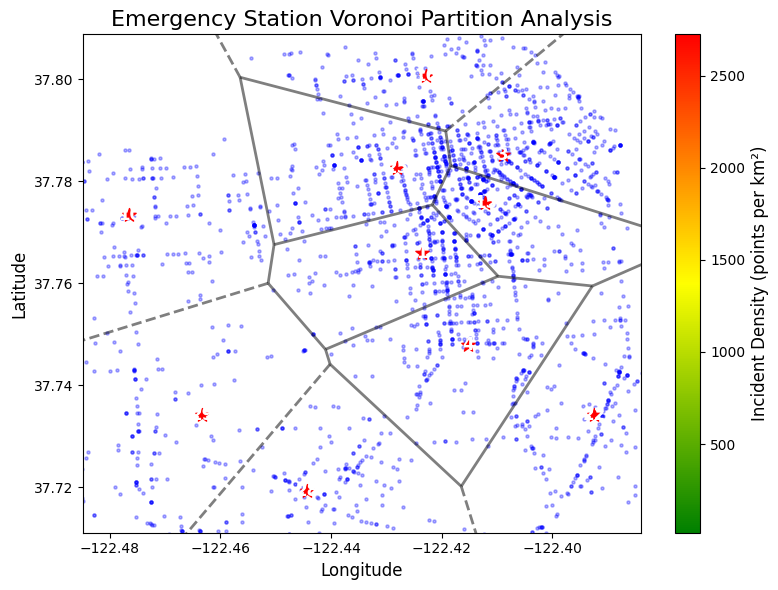

In [ ]:
fig = static_voronoi_plot(
    voronoi_analysis=voronoi_analysis_P10,
    selected_sites=[solver_P10.potential_sites[idx] for idx in results_P10['selected_sites']],
    site_indices=results_P10['selected_sites'],
    demand_points=solver_P10.demand_points,  # 需求点，可选
    weights=None,  # 如果需求点有权重可以传数组；没有就None
    output_file='voronoi_static_P8.png'  # 输出文件名
)

In [ ]:
def analyze_coverage_efficiency(demand_points, weights, selected_sites, site_indices, max_distances=[1, 2, 3, 5]):
    """
    分析救护站覆盖效率

    Parameters:
    -----------
    demand_points : array-like
        需求点坐标 (纬度, 经度)
    weights : array-like
        需求点权重
    selected_sites : array-like
        选中的站点坐标 (纬度, 经度)
    site_indices : list
        选中站点的索引
    max_distances : list
        分析不同最大覆盖距离（公里）的效率

    Returns:
    --------
    dict : 包含覆盖效率分析结果的字典
    """
    # 将坐标转换为弧度用于Haversine距离计算
    demand_rad = np.radians(demand_points)
    sites_rad = np.radians(selected_sites)

    # 计算每个需求点到最近站点的距离
    min_distances = np.zeros(len(demand_points))
    assigned_sites = np.zeros(len(demand_points), dtype=int)

    for i, point_rad in enumerate(demand_rad):
        min_dist = float('inf')
        nearest_site = -1

        for j, site_rad in enumerate(sites_rad):
            # 计算Haversine距离
            dlat = site_rad[0] - point_rad[0]
            dlon = site_rad[1] - point_rad[1]

            a = np.sin(dlat/2)**2 + np.cos(point_rad[0]) * np.cos(site_rad[0]) * np.sin(dlon/2)**2
            c = 2 * np.arcsin(np.sqrt(a))

            # 地球半径（公里）
            earth_radius = 6371.0
            dist = earth_radius * c

            if dist < min_dist:
                min_dist = dist
                nearest_site = j

        min_distances[i] = min_dist
        assigned_sites[i] = nearest_site

    # 分析不同最大覆盖距离的覆盖率
    coverage_analysis = {}

    for max_dist in max_distances:
        # 计算在最大距离内的需求点比例
        covered_mask = min_distances <= max_dist
        covered_count = np.sum(covered_mask)
        covered_ratio = covered_count / len(demand_points)

        # 计算权重覆盖率
        if weights is not None:
            total_weight = np.sum(weights)
            covered_weight = np.sum(weights[covered_mask])
            weighted_covered_ratio = covered_weight / total_weight
        else:
            weighted_covered_ratio = covered_ratio

        # 计算每个站点的覆盖情况
        site_coverage = {}
        for j in range(len(selected_sites)):
            site_idx = site_indices[j]

            # 找到分配给该站点且在最大距离内的需求点
            site_mask = (assigned_sites == j) & covered_mask
            site_covered_count = np.sum(site_mask)

            # 计算该站点的覆盖权重
            if weights is not None:
                site_covered_weight = np.sum(weights[site_mask])
            else:
                site_covered_weight = site_covered_count

            # 计算该站点在最大距离内的平均响应距离
            if site_covered_count > 0:
                avg_response_dist = np.mean(min_distances[site_mask])
            else:
                avg_response_dist = None

            site_coverage[site_idx] = {
                'covered_count': int(site_covered_count),
                'covered_weight': float(site_covered_weight),
                'avg_response_dist': float(avg_response_dist) if avg_response_dist is not None else None
            }

        coverage_analysis[max_dist] = {
            'covered_count': int(covered_count),
            'covered_ratio': float(covered_ratio),
            'weighted_covered_ratio': float(weighted_covered_ratio),
            'site_coverage': site_coverage
        }

    # 计算平均响应时间（假设平均速度为40公里/小时）
    avg_speed_kmh = 40.0
    avg_response_time_min = np.mean(min_distances) / avg_speed_kmh * 60

    # 计算90%分位数响应时间
    percentile_90_dist = np.percentile(min_distances, 90)
    percentile_90_time_min = percentile_90_dist / avg_speed_kmh * 60

    # 返回完整分析结果
    return {
        'min_distances': min_distances,
        'assigned_sites': assigned_sites,
        'coverage_by_distance': coverage_analysis,
        'avg_response_distance_km': float(np.mean(min_distances)),
        'avg_response_time_min': float(avg_response_time_min),
        'percentile_90_distance_km': float(percentile_90_dist),
        'percentile_90_time_min': float(percentile_90_time_min)
    }

In [ ]:
selected_sites = np.array([solver_P10.potential_sites[idx] for idx in results_P10['selected_sites']])
site_indices = results_P10['selected_sites']

demand_points = np.array(solver_P10.demand_points)
weights = np.array(solver_P10.weights)

efficiency_results = analyze_coverage_efficiency(
    demand_points=demand_points,
    weights=weights,
    selected_sites=selected_sites,
    site_indices=site_indices,
    max_distances=[1, 2, 3, 5]
)

print(f"Average Response Distance: {efficiency_results['avg_response_distance_km']:.2f} km")
print(f"Average Response Time: {efficiency_results['avg_response_time_min']:.2f} minutes")

coverage_3km = efficiency_results['coverage_by_distance'][3]
print(f"3km Coverage Ratio: {coverage_3km['covered_ratio']:.2%}")
print(f"3km Weighted Coverage Ratio: {coverage_3km['weighted_covered_ratio']:.2%}")

Average Response Distance: 1.06 km
Average Response Time: 1.59 minutes
3km Coverage Ratio: 98.76%
3km Weighted Coverage Ratio: 98.51%


In [ ]:
def visualize_coverage_efficiency(coverage_analysis, output_file='coverage_efficiency.png'):
    """
    Visualize the coverage efficiency analysis results.

    Parameters:
    -----------
    coverage_analysis : dict
        Output from analyze_coverage_efficiency()
    output_file : str
        Output PNG file name
    """
    # Create figure
    fig, axs = plt.subplots(2, 2, figsize=(16, 12))

    # 1. Plot coverage ratio at different maximum distances
    distances = sorted(coverage_analysis['coverage_by_distance'].keys())
    covered_ratios = [coverage_analysis['coverage_by_distance'][d]['covered_ratio'] for d in distances]
    weighted_ratios = [coverage_analysis['coverage_by_distance'][d]['weighted_covered_ratio'] for d in distances]

    ax1 = axs[0, 0]
    ax1.plot(distances, covered_ratios, 'o-', label='Coverage Ratio')
    ax1.plot(distances, weighted_ratios, 's-', label='Weighted Coverage Ratio')

    ax1.set_xlabel('Maximum Coverage Distance (km)')
    ax1.set_ylabel('Coverage Ratio')
    ax1.set_title('Coverage Ratio vs Maximum Distance')
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    for i, d in enumerate(distances):
        ax1.annotate(f'{covered_ratios[i]:.1%}',
                    (d, covered_ratios[i]),
                    textcoords="offset points",
                    xytext=(0, 10),
                    ha='center')
        ax1.annotate(f'{weighted_ratios[i]:.1%}',
                    (d, weighted_ratios[i]),
                    textcoords="offset points",
                    xytext=(0, 10),
                    ha='center')

    # 2. Plot distribution of response distances
    ax2 = axs[0, 1]
    sns.histplot(coverage_analysis['min_distances'], bins=20, kde=True, ax=ax2)

    avg_dist = coverage_analysis['avg_response_distance_km']
    p90_dist = coverage_analysis['percentile_90_distance_km']

    ax2.axvline(avg_dist, color='red', linestyle='--', label=f'Average Distance: {avg_dist:.2f} km')
    ax2.axvline(p90_dist, color='green', linestyle='--', label=f'90th Percentile Distance: {p90_dist:.2f} km')

    ax2.set_xlabel('Distance to Nearest Station (km)')
    ax2.set_ylabel('Frequency')
    ax2.set_title('Distribution of Response Distances')
    ax2.legend()

    # 3. Plot number of incidents covered within 3 km per station
    ax3 = axs[1, 0]

    if 3 in coverage_analysis['coverage_by_distance']:
        site_coverage = coverage_analysis['coverage_by_distance'][3]['site_coverage']
        site_indices = sorted(site_coverage.keys())
        covered_counts = [site_coverage[idx]['covered_count'] for idx in site_indices]

        ax3.bar(range(len(site_indices)), covered_counts)
        ax3.set_xticks(range(len(site_indices)))
        ax3.set_xticklabels(site_indices)

        ax3.set_xlabel('Station Index')
        ax3.set_ylabel('Number of Covered Incidents (within 3 km)')
        ax3.set_title('Covered Incidents per Station (3 km range)')

        for i, count in enumerate(covered_counts):
            ax3.annotate(str(count),
                        (i, count),
                        textcoords="offset points",
                        xytext=(0, 5),
                        ha='center')
    else:
        ax3.text(0.5, 0.5, 'No data for 3 km coverage range',
                 ha='center', va='center', transform=ax3.transAxes)

    # 4. Plot average response time per station
    ax4 = axs[1, 1]

    if 3 in coverage_analysis['coverage_by_distance']:
        site_coverage = coverage_analysis['coverage_by_distance'][3]['site_coverage']
        site_indices = sorted(site_coverage.keys())

        avg_response_dists = []
        for idx in site_indices:
            dist = site_coverage[idx]['avg_response_dist']
            if dist is not None:
                avg_response_dists.append(dist)
            else:
                avg_response_dists.append(0)

        avg_speed_kmh = 40.0
        avg_response_times = [d / avg_speed_kmh * 60 for d in avg_response_dists]

        ax4.bar(range(len(site_indices)), avg_response_times)
        ax4.set_xticks(range(len(site_indices)))
        ax4.set_xticklabels(site_indices)

        ax4.set_xlabel('Station Index')
        ax4.set_ylabel('Average Response Time (minutes)')
        ax4.set_title('Average Response Time per Station (within 3 km)')

        for i, time in enumerate(avg_response_times):
            ax4.annotate(f'{time:.1f}',
                        (i, time),
                        textcoords="offset points",
                        xytext=(0, 5),
                        ha='center')
    else:
        ax4.text(0.5, 0.5, 'No data for 3 km coverage range',
                 ha='center', va='center', transform=ax4.transAxes)

    # Set overall title and layout
    fig.suptitle('Emergency Station Coverage Efficiency Analysis', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])

    # Save the figure
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"Coverage efficiency analysis plot saved to {output_file}")

    return fig

Coverage efficiency analysis plot saved to coverage_efficiency.png


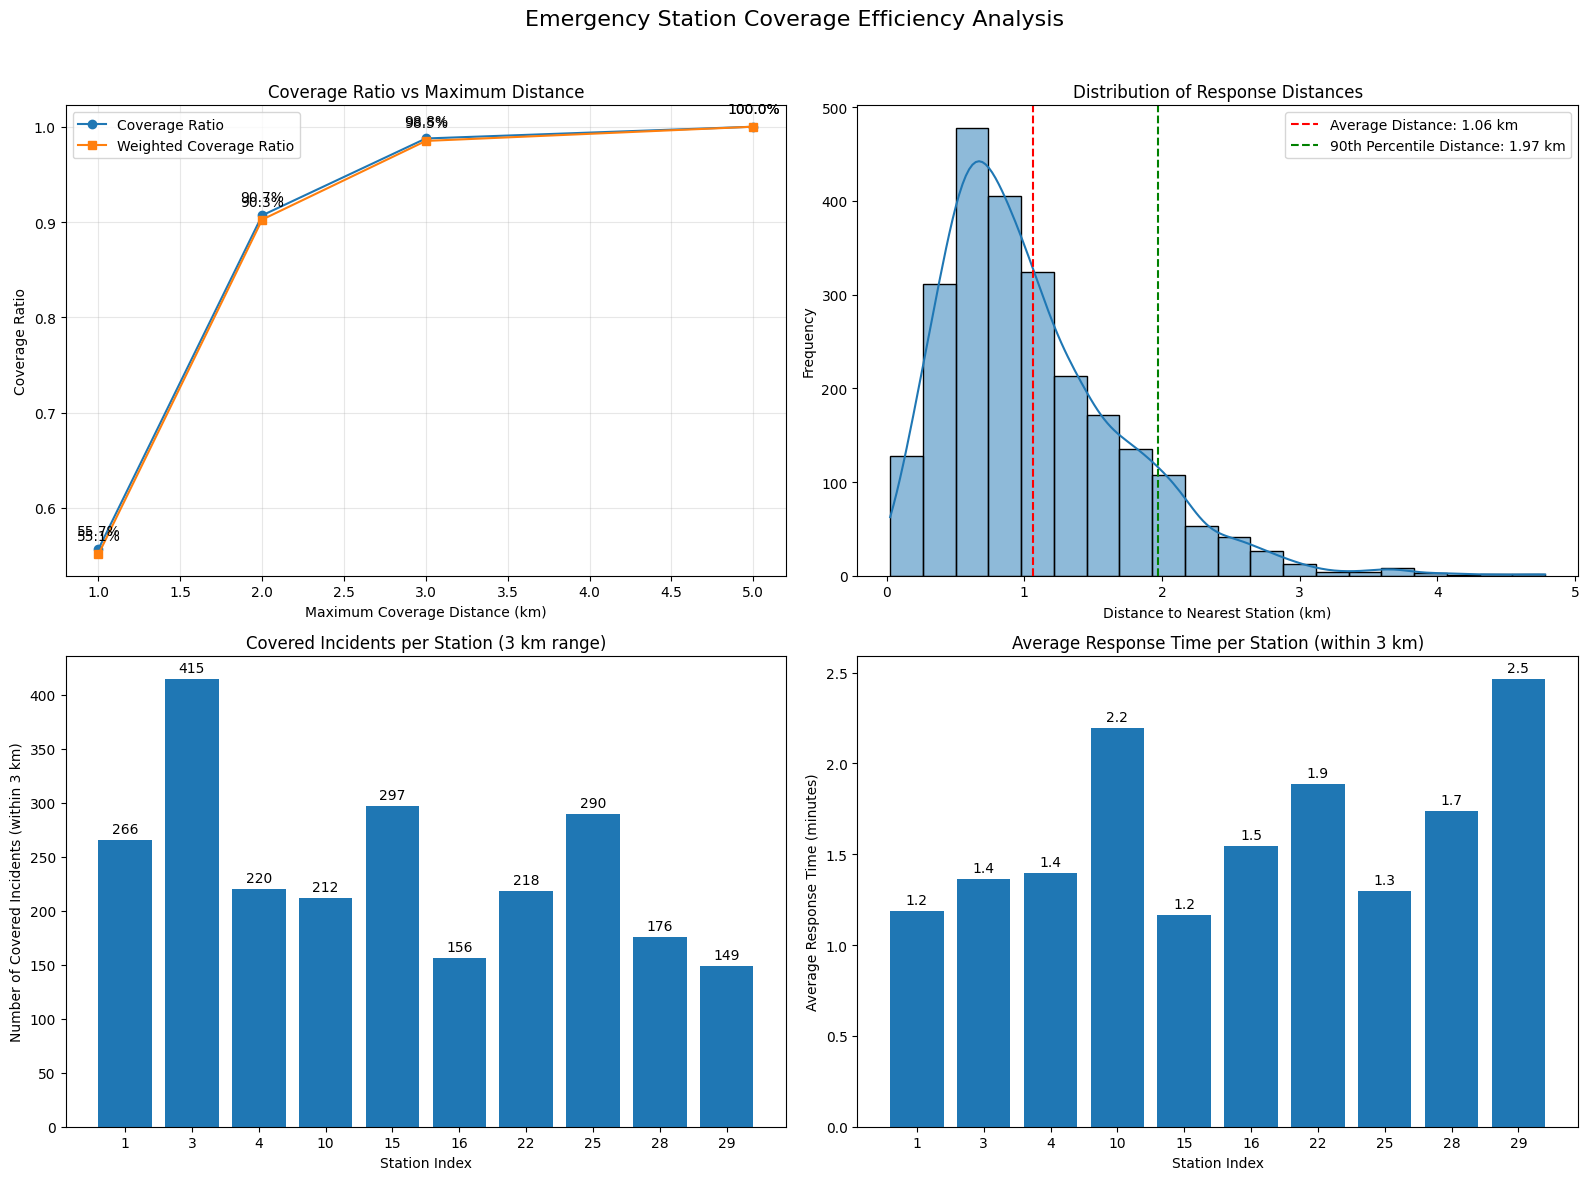

In [ ]:
fig = visualize_coverage_efficiency(efficiency_results)